### This notebook compute "VCA3. Number of hydraulic and natural infrastrcture works for water storage and distribution " indicator for the 27 basins of IKI Project

Spanish: Número de obras de infraestructura hidráulica y natural para el almacenamiento y distribución del agua

**Created:** 11/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**
**Status:** Complete. Update needed with additional data. See future work.
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
 
**Inputs:**   Shapefile of COMIDs and districts, INEI report downloaded from http://censos1.inei.gob.pe/Cenagro/redatam/# (base de datos REDATAM - CENAGRO 201240, información sobre pequeñosreservorios/embalses de regulación estacional según el número de equipos a nivel
distrital. Para ello, dirígete a la sección Condiciones de la actividad agropecuaria y selecciona Infraestructura.). Needed to resave the .xsl as an .xlsx to work correctly.

**Outputs:** Indicator value 
 
**Assumptions:** Assuming 2012 data to be "current" given it is the data we have. Using weighted method for assigning district-level data to COMIDs. 

Also, adds in canales and bocotomas counts that we have (subset of infrastructure that we have for E2 indicator)
 
AFilling in N/A for zero as needed. 

**Future work:** 

Does not have the following information included: info de Agro Rural y UE Fondo Sierra Azul sobre las acciones de recarga
hídrica para siembra y cosecha de agua, es decir, diques para cochas, zanjas de infiltración,
reforestación, vegetación, entre otros.
 
**Notes:** 

**Normilization:** Needs to be normalized with min/max equation. 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
#SETTINGS

#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 503 #Indicator ID ((Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

In [3]:
#INPUTS

#Define District_within_COMID fractions csv - this allows for a weighted method to be used for assigning district level data to subbasins
district_area_within_COMID= pd.read_csv(f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/COMID_District_Fractions.csv')

subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in excel from INEI (open in Excel and save xls as xlsx as needed before reading in)
infra= pd.read_excel(f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2a_Metodologia/Indicadores/Vulnerabilidad/INEI_reporte_VCA3.xlsx')

top_row_name= 'Infraestructura agropecuaria'

#INFRA SHAPEFILES
#read in bocatomas 
bocatomas_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Bocatomas.shp'
#read in presas
presas_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/GIS/4_DEMANDAS_DEMANDS/Datos_ANA/Presas.shp'
#read in canals 
canals_tras_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalTrasvase.shp'
canals_lat_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalLateral.shp'
canals_ad_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalAduccion.shp'
canals_der_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalDerivacion.shp'

In [4]:
#FORMATTING THE DATAFRAME

#remove empty rows 
infra = infra.dropna(axis=0, how='all')  # Drop rows that are completely NaN
#remove unnamed: 1 and and unnamed: 3 columns
infra = infra.drop(columns=['Unnamed: 1', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')
#Keep only rows with 'Pequeño reservorio / Embalse de regulación estacional' or 'AREA' in 'Infraestructura agropecuaria' column
infra = infra[infra[top_row_name].str.contains('Pequeño reservorio|AREA', case=False, na=False)]

#Replace 'Pequeño reservorio / Embalse de regulación estacional' with 'TOTAL' in 'Infraestructura agropecuaria' column
infra[top_row_name] = infra[top_row_name].str.replace('Pequeño reservorio / Embalse de regulación estacional', 'TOTAL', regex=False)

indices_to_drop = []
# Iterate through the rows to check for AREA rows and their corresponding Total rows
for i in range(len(infra) - 1):  # Stop at the second-to-last row to avoid index errors
    if 'AREA' in str(infra.iloc[i][top_row_name]).upper():  # Check if the current row is an AREA row
        next_row = infra.iloc[i + 1]
        if 'TOTAL' in str(next_row[top_row_name]).upper():  # Check if the next row is a Total row
            # Assign the value from the next row to the "Total Heads" column of the current row
            infra.at[infra.index[i], 'Total_Dist'] = next_row['Unnamed: 2']
            # Mark the Total row for dropping
            indices_to_drop.append(infra.index[i + 1])

# Drop all marked indices at once
infra.drop(index=indices_to_drop, inplace=True)

# Reset the index after dropping rows
infra.reset_index(drop=True, inplace=True)

# Convert Total_Dist to numeric, coercing errors to NaN, then fill NaN with 0 for summing
infra['Total_Dist'] = pd.to_numeric(infra['Total_Dist'], errors='coerce').fillna(0)

#remove all rows from Temas that are NA
infra = infra.dropna(subset=[top_row_name])

infra = infra.drop(columns=['Unnamed: 2'], errors='ignore')

# Extract IDDIST (district ID) from the top_row_name column# Drop the Unnamed: 2 column

# The format is "AREA # XXXXX" where XXXXX is the district ID
infra['IDDIST'] = infra[top_row_name].str.extract(r'AREA # (\d+)')[0]

In [6]:
#WEIGHTED METHOD FUNCTION 
# For each COMID, calculate proportionate lighting values based on district area fractions
#could amplify this fraction so it could read in any value by IDDIST 
def calculate_proportionate_values(district_fractions_df, value_df, column_name, comid_list):
    """
    Calculate proportionate values for each COMID based on district area fractions
    
    Parameters:
    - district_fractions_df: DataFrame with COMID, DISTRICT, district_area_within_COMID_fraction
    - value_df: DataFrame with IDDIST and indicator values
    - column_name: Name of the column containing the indicator values
    - comid_list: List of COMIDs to process
    
    Returns:
    - DataFrame with COMID and proportionate_indicator_value
    """
    # Ensure IDDIST and DISTRICT columns are in the same format
    value_df = value_df.copy()
    district_fractions_df = district_fractions_df.copy()
    
    value_df['IDDIST'] = value_df['IDDIST'].astype(str).str.strip()
    district_fractions_df['DISTRICT'] = district_fractions_df['DISTRICT'].astype(str).str.strip()
    
    results = []
    
    for comid in comid_list:
        # Get all districts within this COMID
        districts_in_comid = district_fractions_df[district_fractions_df['COMID'] == comid]
        
        total_proportionate_value = 0
        
        for _, row in districts_in_comid.iterrows():
            district_id = row['DISTRICT']
            fraction = row['district_area_within_COMID_fraction']
            # Get the indicator value for this district
            ind_value = value_df[value_df['IDDIST'] == district_id][column_name].values

            if len(ind_value) > 0:
                # Multiply district value by the fraction of area within COMID
                proportionate_value = ind_value[0] * fraction
                total_proportionate_value += proportionate_value
        
        results.append({
            'COMID': comid,
            'proportionate_indicator_value': total_proportionate_value
        })
    
    return pd.DataFrame(results)

In [7]:
# WEIGHTED METHOD: Calculate proportionate values based on district area fractions within each COMID

# Prepare district data for weighted method
infra_weighted = infra.copy()

# Get list of all COMIDs
comid_list = subbasins_gdf['COMID'].unique().tolist()

# Calculate proportionate values using weighted method
weighted_results = calculate_proportionate_values(
    district_fractions_df=district_area_within_COMID,
    value_df=infra_weighted,
    column_name='Total_Dist',
    comid_list=comid_list
)

# Merge weighted results back to subbasins
subbasins_gdf = subbasins_gdf.merge(
    weighted_results,
    on='COMID',
    how='left'
)

# Rename the proportionate value column for clarity
subbasins_gdf = subbasins_gdf.rename(columns={'proportionate_indicator_value': 'Total_Dist_Weighted'})

print(f"Weighted method applied. Total COMIDs: {len(subbasins_gdf)}")
print(f"\nSummary statistics for Total_Dist_Weighted:")
print(subbasins_gdf['Total_Dist_Weighted'].describe())

Weighted method applied. Total COMIDs: 3655

Summary statistics for Total_Dist_Weighted:
count    3655.000000
mean        1.979516
std        10.525681
min         0.000000
25%         0.000000
50%         0.000000
75%         0.523743
max       314.472893
Name: Total_Dist_Weighted, dtype: float64


In [8]:
# COUNT HYDRAULIC INFRASTRUCTURE AND DISTRIBUTION FEATURES PER COMID

# Ensure all infrastructure shapefiles have the same CRS as the subbasin shapefile
subbasins_crs = subbasins_gdf.crs

# Load and reproject infrastructure shapefiles
bocatomas_gdf = gpd.read_file(bocatomas_shp).to_crs(subbasins_crs)
presas_gdf = gpd.read_file(presas_shp).to_crs(subbasins_crs)
canals_tras_gdf = gpd.read_file(canals_tras_shp).to_crs(subbasins_crs)
canals_lat_gdf = gpd.read_file(canals_lat_shp).to_crs(subbasins_crs)
canals_ad_gdf = gpd.read_file(canals_ad_shp).to_crs(subbasins_crs)
canals_der_gdf = gpd.read_file(canals_der_shp).to_crs(subbasins_crs)

# Perform spatial join to count features within each COMID
bocatomas_per_comid = gpd.sjoin(bocatomas_gdf, subbasins_gdf[['COMID', 'geometry']], 
                                  how='inner', predicate='within').groupby('COMID').size().reset_index(name='bocatomas_count')

presas_per_comid = gpd.sjoin(presas_gdf, subbasins_gdf[['COMID', 'geometry']], 
                               how='inner', predicate='within').groupby('COMID').size().reset_index(name='presas_count')

# For canals (line features), use intersects instead of within
canals_tras_per_comid = gpd.sjoin(canals_tras_gdf, subbasins_gdf[['COMID', 'geometry']], 
                                    how='inner', predicate='intersects').groupby('COMID').size().reset_index(name='canals_tras_count')

canals_lat_per_comid = gpd.sjoin(canals_lat_gdf, subbasins_gdf[['COMID', 'geometry']], 
                                   how='inner', predicate='intersects').groupby('COMID').size().reset_index(name='canals_lat_count')

canals_ad_per_comid = gpd.sjoin(canals_ad_gdf, subbasins_gdf[['COMID', 'geometry']], 
                                  how='inner', predicate='intersects').groupby('COMID').size().reset_index(name='canals_ad_count')

canals_der_per_comid = gpd.sjoin(canals_der_gdf, subbasins_gdf[['COMID', 'geometry']], 
                                   how='inner', predicate='intersects').groupby('COMID').size().reset_index(name='canals_der_count')

# Merge all counts back to subbasins_gdf
subbasins_gdf = subbasins_gdf.merge(bocatomas_per_comid, on='COMID', how='left')
subbasins_gdf = subbasins_gdf.merge(presas_per_comid, on='COMID', how='left')
subbasins_gdf = subbasins_gdf.merge(canals_tras_per_comid, on='COMID', how='left')
subbasins_gdf = subbasins_gdf.merge(canals_lat_per_comid, on='COMID', how='left')
subbasins_gdf = subbasins_gdf.merge(canals_ad_per_comid, on='COMID', how='left')
subbasins_gdf = subbasins_gdf.merge(canals_der_per_comid, on='COMID', how='left')

# Fill NaN values with 0 (COMIDs without any infrastructure)
infrastructure_columns = ['bocatomas_count', 'presas_count', 'canals_tras_count', 
                          'canals_lat_count', 'canals_ad_count', 'canals_der_count']
subbasins_gdf[infrastructure_columns] = subbasins_gdf[infrastructure_columns].fillna(0)

# Calculate total infrastructure count per COMID
subbasins_gdf['Total_Infrastructure_Count'] = subbasins_gdf[infrastructure_columns].sum(axis=1)

# Add weighted INEI data to total infrastructure count
subbasins_gdf['Total_Dist_Weighted'] = subbasins_gdf['Total_Dist_Weighted'].fillna(0)
subbasins_gdf['Total_VCA3'] = subbasins_gdf['Total_Dist_Weighted'] + subbasins_gdf['Total_Infrastructure_Count']

# Round to 2 decimal places
subbasins_gdf['Total_VCA3'] = subbasins_gdf['Total_VCA3'].round(2)

print(f"\nInfrastructure counts per COMID:")
print(f"Total bocatomas: {subbasins_gdf['bocatomas_count'].sum()}")
print(f"Total presas: {subbasins_gdf['presas_count'].sum()}")
print(f"Total canals (all types): {subbasins_gdf[['canals_tras_count', 'canals_lat_count', 'canals_ad_count', 'canals_der_count']].sum().sum()}")
print(f"\nSummary statistics for Total_VCA3:")
print(subbasins_gdf['Total_VCA3'].describe())


Infrastructure counts per COMID:
Total bocatomas: 24684.0
Total presas: 49.0
Total canals (all types): 56029.0

Summary statistics for Total_VCA3:
count    3655.000000
mean       24.075874
std        68.049357
min         0.000000
25%         0.000000
50%         1.570000
75%        19.340000
max      1385.000000
Name: Total_VCA3, dtype: float64


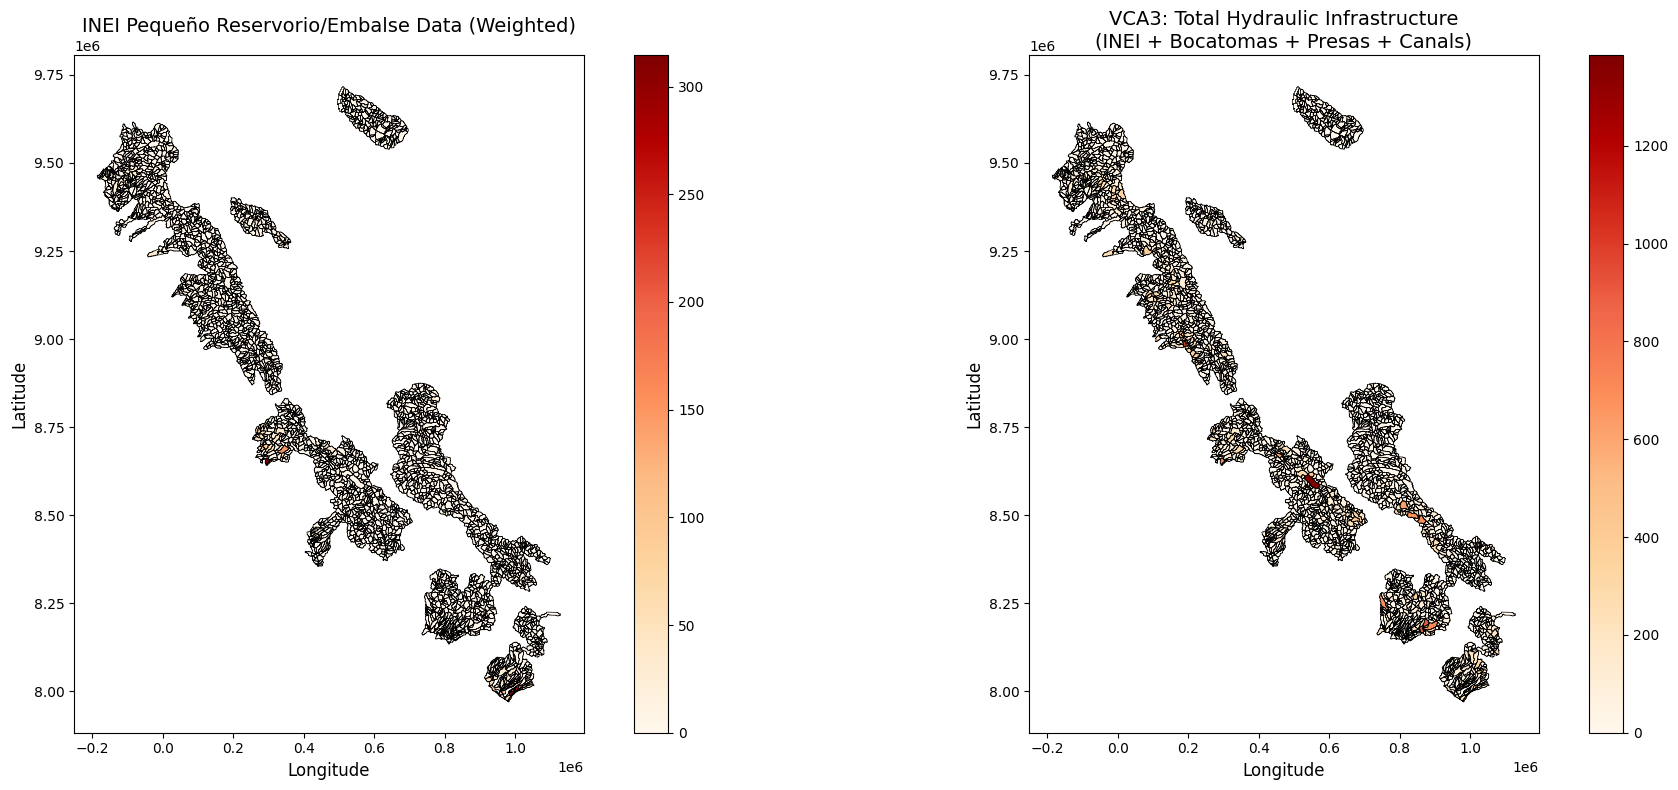


=== Infrastructure Summary ===
COMIDs with bocatomas: 1454
COMIDs with presas: 27
COMIDs with canals: 1627
COMIDs with INEI data: 1825
COMIDs with any infrastructure: 2614


In [9]:
#PLOTTING

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Weighted INEI data only
subbasins_gdf.plot(column='Total_Dist_Weighted', cmap='OrRd', legend=True, ax=ax1, 
                   edgecolor='black', linewidth=0.5)
ax1.set_title('INEI Pequeño Reservorio/Embalse Data (Weighted)', fontsize=14)
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)

# Plot 2: Total VCA3 (INEI + Infrastructure counts)
subbasins_gdf.plot(column='Total_VCA3', cmap='OrRd', legend=True, ax=ax2, 
                   edgecolor='black', linewidth=0.5)
ax2.set_title('VCA3: Total Hydraulic Infrastructure\n(INEI + Bocatomas + Presas + Canals)', fontsize=14)
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary by infrastructure type
print("\n=== Infrastructure Summary ===")
print(f"COMIDs with bocatomas: {(subbasins_gdf['bocatomas_count'] > 0).sum()}")
print(f"COMIDs with presas: {(subbasins_gdf['presas_count'] > 0).sum()}")
print(f"COMIDs with canals: {(subbasins_gdf[['canals_tras_count', 'canals_lat_count', 'canals_ad_count', 'canals_der_count']].sum(axis=1) > 0).sum()}")
print(f"COMIDs with INEI data: {(subbasins_gdf['Total_Dist_Weighted'] > 0).sum()}")
print(f"COMIDs with any infrastructure: {(subbasins_gdf['Total_VCA3'] > 0).sum()}")

SQLITE INSERT 

In [10]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_gdf #COMID and Total_Dist
value_column= 'Total_VCA3' #Column with the calculated indicator values

In [11]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [12]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [13]:
df_check.describe()

,ScnID,IndID,COMID,Value
count,3655.0,3655.0,3.655000e+03,3655.000000
mean,1.0,503.0,3.085487e+08,24.075874
std,0.0,0.0,2.145454e+06,68.049357
min,1.0,503.0,3.042739e+08,0.000000
25%,1.0,503.0,3.066237e+08,0.000000
50%,1.0,503.0,3.091100e+08,1.570000
75%,1.0,503.0,3.102598e+08,19.340000
max,1.0,503.0,3.202546e+08,1385.000000


In [14]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()